In [58]:
# from read_multi_ase_simple import *
from extract_simple import *

import sys 
import os 

import torch
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt

# from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool, Sequential, AttentionalAggregation
from torch_geometric.loader import DataLoader
from tqdm import tqdm

In [59]:
parent_dir = os.path.abspath(os.path.join('..'))
sys.path.append(parent_dir)

In [60]:
my_path = '../../data'

# --------- EDIT THIS VALUE TO CHANGE EFFECTIVE DATASET SIZE -------------
max_mols = 500

files_list = find_files(my_path)

# Process files from list and extract specified number of molecules and type
dataset = process_file(files_list, molecule_type = 'biomolecules', max_molecules = max_mols)

# Get final dataset for use with PyG 
torch_data = get_data(dataset)

final_dataset = split_data(torch_data, 0.8)

Processed 500 atoms


In [61]:
train_dataset = final_dataset[0]
val_dataset = final_dataset[1]

print(len(train_dataset), len(val_dataset))

400 100


In [62]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [63]:
# inherit from nn.Module 
class SimpleGNN(nn.Module):
    def __init__(self, num_node_features=1, hidden_channels=128):
        # call constructor from parent class 
        super().__init__()

        self.simpleGNN = Sequential('x, edge_index, batch', [
            # CONVOLUTION LAYERS: learn molecular represenation 
            # layer 1: directly bonded atoms
            (GCNConv(num_node_features, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 2: local chemical environment (i.e., funct groups)
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 3: adds global context
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),

            # POOLING: down-sample/reduce dimensions 
            (global_mean_pool, 'x, batch -> x'),

            # LINEAR LAYERS: turn into actual predictions 
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)])


    def forward(self, x, edge_index, batch):
        return self.simpleGNN(x, edge_index, batch).reshape(-1)

In [64]:
# inherit from nn.Module 
class AttentionGNN(nn.Module):
    def __init__(self, num_node_features=1, hidden_channels=128):
        # call constructor from parent class 
        super().__init__()

        # define attention pooling
        self.attention_pool = AttentionalAggregation(
            gate_nn=nn.Sequential(
                nn.Linear(hidden_channels, hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, 1)))

        self.attention = Sequential('x, edge_index, batch', [
            # CONVOLUTION LAYERS: learn molecular represenation 
            # layer 1: directly bonded atoms
            (GCNConv(num_node_features, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 2: local chemical environment (i.e., funct groups)
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 3: adds global context
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),

            # POOLING: down-sample/reduce dimensions 
            (self.attention_pool, 'x, batch -> x'),

            # LINEAR LAYERS: turn into actual predictions 
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)])


    def forward(self, x, edge_index, batch):
        return self.attention(x, edge_index, batch).reshape(-1)

In [65]:
# code taken from Module 9 bloodmnist_pytroch.ipynb demo 

NUM_EPOCHS = 50

def train_model(model, train_loader, val_loader, loss_fn, optimizer,
                epochs=10, print_every=1, device='cpu'):

    # for keeping track of total loss
    history = {'train_loss': [], 'val_loss': [],
               'train_mae': [], 'val_mae': [],
               'train_rmse': [], 'val_rmse': []}


    model = model.to(device) # move to device (cpu/gpu/mps as specified)

    for epoch in tqdm(range(epochs), desc='Training'):
        # TRAINING
        model.train()
        
        # initialize losses to 0 at start of each epoch 
        epoch_train_loss = 0.0
        epoch_train_mae = 0.0
        epoch_train_rmse = 0.0
        train_n = 0

        # iterate thru each batch 
        for batch in train_loader:
            batch = batch.to(device) # move to specified device 

            # inputs [x, edge_index, batch]
            predictions = model(batch.x, batch.edge_index, batch.batch).reshape(-1)
            targets = batch.y.reshape(-1).float().to(device) # reshape 

            # compare to target and calculate loss 
            loss = loss_fn(predictions, targets)

            optimizer.zero_grad() # zero out grads
            loss.backward() # back-prop 
            optimizer.step() # update/adjust 

            # calculate losses 
            epoch_train_loss += loss.item() # from optimizer 
            epoch_train_mae += torch.abs(predictions - targets).sum().item()
            epoch_train_rmse += ((predictions - targets) ** 2).sum().item()
            train_n += targets.numel()

        # calculate avg loss
        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_train_mae = epoch_train_mae / train_n
        avg_train_rmse = (epoch_train_rmse / train_n) ** 0.5

        # Validation
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_mae = 0.0
        epoch_val_rmse = 0.0
        val_n = 0

        with torch.no_grad():
            for val_batch in val_loader:
                val_batch = val_batch.to(device)

                val_predictions = model(val_batch.x, val_batch.edge_index, val_batch.batch).reshape(-1)
                val_targets = val_batch.y.reshape(-1).float().to(device)

                val_loss = loss_fn(val_predictions, val_targets)

                epoch_val_loss += val_loss.item()

                epoch_val_mae += torch.abs(val_predictions - val_targets).sum().item()
                epoch_val_rmse += ((val_predictions - val_targets) ** 2).sum().item()
                val_n += val_targets.numel()

        avg_val_loss = epoch_val_loss / len(val_loader)
        avg_val_mae = epoch_val_mae / val_n
        avg_val_rmse = (epoch_val_rmse / val_n) ** 0.5


        # Record
        history['train_loss'].append(avg_train_loss)
        history['train_mae'].append(avg_train_mae)
        history['train_rmse'].append(avg_train_rmse)

        history['val_loss'].append(avg_val_loss)
        history['val_mae'].append(avg_val_mae)
        history['val_rmse'].append(avg_val_rmse)
        
        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {avg_val_loss:.4f}"
            )

    return history

In [66]:
def plot_mae_rmse(history, model_name):
    """Plot training vs validation loss from a history dict."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].plot(history['train_mae'], label='Train', linewidth=2)
    ax[0].plot(history['val_mae'], label='Validation',
             linewidth=2, linestyle='--')
    ax[0].set_title(f'MAE')
    # ax[0].set_xlim(4)
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    ax[1].plot(history['train_rmse'], label='Train', linewidth=2)
    ax[1].plot(history['val_rmse'], label='Validation',
             linewidth=2, linestyle='--')
    ax[1].set_title(f'RMSE')
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    fig.suptitle(f"MAE and RMSE for {model_name}")

    plt.tight_layout()
    plt.show()

## SimpleGNN

In [67]:
# initialize model 
simpleGNN = SimpleGNN()

my_lr = 1e-3 # decreasing this val -> smoother loss curves 
my_loss_fn = nn.SmoothL1Loss()
my_optimizer = optim.Adam(simpleGNN.parameters(), lr=my_lr)

In [68]:
history = train_model(
    model = simpleGNN, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    loss_fn = my_loss_fn,
    optimizer = my_optimizer,
    epochs = 50,
    print_every = 5
)

Training:  10%|█         | 5/50 [00:02<00:20,  2.14it/s]

Epoch   5/50 | Train Loss: 1.5636 | Val Loss: 1.7537


Training:  20%|██        | 10/50 [00:04<00:18,  2.21it/s]

Epoch  10/50 | Train Loss: 1.5458 | Val Loss: 1.8849


Training:  30%|███       | 15/50 [00:06<00:15,  2.27it/s]

...

Epoch  40/50 | Train Loss: 0.8390 | Val Loss: 1.0855


Training:  90%|█████████ | 45/50 [00:20<00:02,  2.28it/s]

Epoch  45/50 | Train Loss: 0.9083 | Val Loss: 1.0820


Training: 100%|██████████| 50/50 [00:22<00:00,  2.24it/s]

Epoch  50/50 | Train Loss: 0.8076 | Val Loss: 1.1889


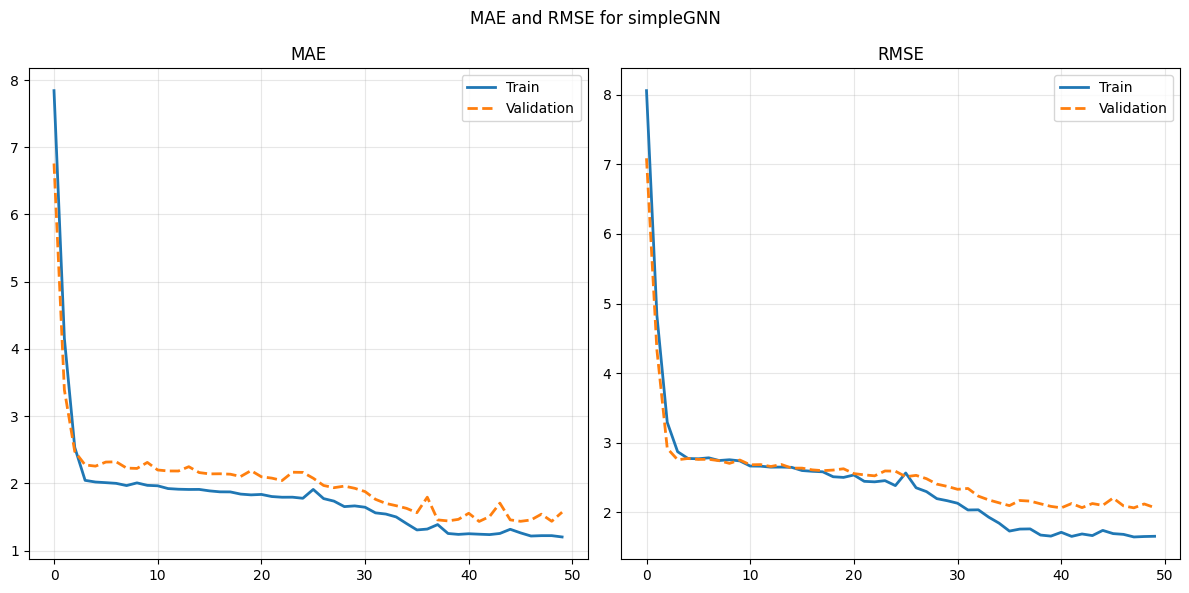

In [69]:
plot_mae_rmse(history, 'simpleGNN')

In [70]:
print(f"Train: Final MAE = {history['train_mae'][-1]:.4f}")
print(f"Validation: Final MAE = {history['val_mae'][-1]:.4f}")

print(f"Train: Final RMSE = {history['train_rmse'][-1]:.4f}")
print(f"Validation: Final RMSE = {history['val_rmse'][-1]:.4f}")

Train: Final MAE = 1.2041
Validation: Final MAE = 1.5726
Train: Final RMSE = 1.6573
Validation: Final RMSE = 2.0693


## SimpleGNN (with attention pooling)

In [71]:
# initialize model 
attentionGNN = AttentionGNN()

my_lr = 1e-3
my_loss_fn = nn.SmoothL1Loss()
my_optimizer = optim.Adam(attentionGNN.parameters(), lr=my_lr)

In [72]:
attn_history = train_model(
    model = attentionGNN, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    loss_fn = my_loss_fn,
    optimizer = my_optimizer,
    epochs = 50,
    print_every = 5
)

Training:  10%|█         | 5/50 [00:02<00:20,  2.20it/s]

Epoch   5/50 | Train Loss: 1.5443 | Val Loss: 1.7739


Training:  20%|██        | 10/50 [00:04<00:18,  2.11it/s]

Epoch  10/50 | Train Loss: 1.3567 | Val Loss: 1.5211


Training:  30%|███       | 15/50 [00:07<00:16,  2.09it/s]

...

Epoch  40/50 | Train Loss: 1.1166 | Val Loss: 1.2747


Training:  90%|█████████ | 45/50 [00:21<00:02,  2.06it/s]

Epoch  45/50 | Train Loss: 0.9291 | Val Loss: 1.1096


Training: 100%|██████████| 50/50 [00:23<00:00,  2.10it/s]

Epoch  50/50 | Train Loss: 0.8238 | Val Loss: 1.1701


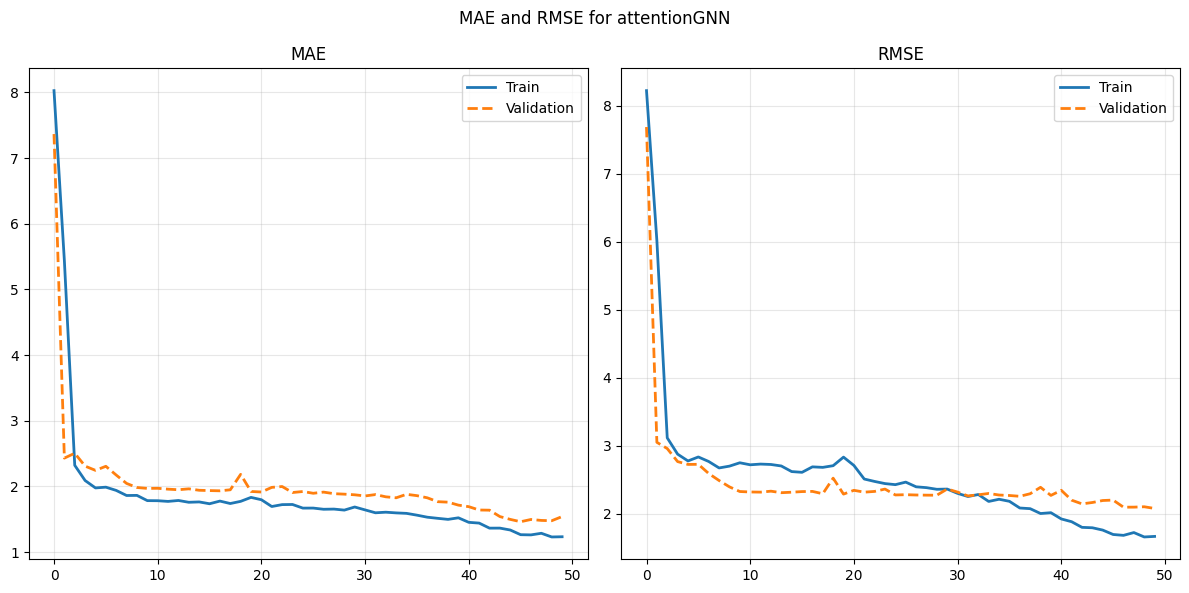

In [73]:
plot_mae_rmse(attn_history, 'attentionGNN')

In [74]:
print(f"Train: Final MAE = {attn_history['train_mae'][-1]:.4f}")
print(f"Validation: Final MAE = {attn_history['val_mae'][-1]:.4f}")

print(f"Train: Final RMSE = {attn_history['train_rmse'][-1]:.4f}")
print(f"Validation: Final RMSE = {attn_history['val_rmse'][-1]:.4f}")

Train: Final MAE = 1.2341
Validation: Final MAE = 1.5415
Train: Final RMSE = 1.6704
Validation: Final RMSE = 2.0816
